<a href="https://colab.research.google.com/github/cleybersilva/AppSGA/blob/master/C%C3%B3pia_de_Exemplo_1_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

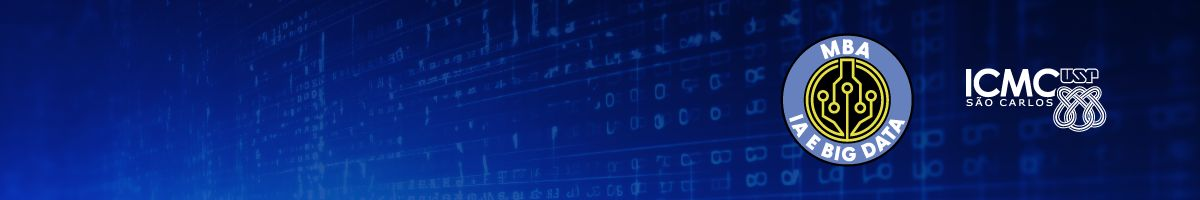

# <font color="red"> MBA em IA e Big Data</font>
## <span style="color:red">Redes Neurais e Deep Learning</span>
## **Exemplo de Uso de LSTM**

### **REDES NEURAIS RECORRENTES**


### Profa. Roseli Ap. Francelin Romero

**PROBLEMA**: SERIE TEMPORAL - Previsão de passageiros de uma Cia Aérea Internacional.

Este é um problema em que, dados um ano e um mês, a tarefa é prever o número de passageiros (em unidades de 1.000) de companhias aéreas internacionais. Os dados variam de janeiro de 1949 a dezembro de 1960,  12 anos, com 144 observações.


Por default o Keras mantem um estado com um batch (stateful=True). Um batch é  no. de linhas do conjunto de dados usado para o treinamento. Entre uma camada e outra na LTSM o estado é desconsiderado por default. Isto nos dá um controle mais fino entre os estados e podemos usar a função resetstates().

**LSTM PARA REGRESSÃO** A cam. LSTM espera uma matriz como entrada: [samples, time steps, features], onde:

**Samples**: são as observações (ou padrões) do dominio da aplicação, normalmente as linhas do dataset.</br>
**Time steps**: são passos de tempo de separação de uma dada variavel para uma dada observação.</br>
**Features**: são medidas separadas observadas em cada tempo da observação.

Nesta série, os seguintes passos serão considerados:

- Carregar o dataset do CSV file.
- Transformar o dataset de modo a adequa-lo para o modelo LSTM, incluindo:
- 1 - Transformar os dados para um problema de aprendizado supervisionado.
- 2 - Transformar os dados para ser "estacionário".
- 3 - Transformar os dados para que fiquem no intervalo [0,1] ou [-1,1].
- 4 - Ajustar o modelo da rede LSTM para o conj. de treinamento.
- 5 - Avaliar o modelo LSTM estático no conjunto de teste.
- 6 - Visualizar o desempenho da Previsão.

Exemplo: 112 118 132 129 121 135 148 ...
   X  Y </br>
 112 118 </br>
 118 132 </br>
 132 129 </br>
 129 121 </br>
 121 135 </br>
 135 148 </br>
 ...

In [ ]:

# LSTM para previsão de passagens em companhia aérea internacional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import callbacks # import callbacks from keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
import seaborn as sns

# converter um array de valores numa matriz de dados
def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):                  #n=5   loop; 0,3    (0,1); (1,2); (2,3); (3,4)
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	return np.array(dataX), np.array(dataY)

# as sementes ajudam a ter resultados reproduzíveis
from numpy.random import seed
seed(1)
from tensorflow.random import set_seed
set_seed(2)

# Carregar o dataset
dataframe = read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv', usecols=[1], engine='python')
dataset = dataframe.values
dataset = dataset.astype('float64')


In [ ]:
# dividir em conjuntos de treinamento e validação
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

In [ ]:
# reshape em X=t and Y=t+1
look_back = 1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

print('X(t)', 'Y(t+1)')
for i in range(len(trainX)):
  print(trainX[i], trainY[i])


X(t) Y(t+1)
[112.] 118.0
[118.] 132.0
[132.] 129.0
[129.] 121.0
[121.] 135.0
[135.] 148.0
[148.] 148.0
[148.] 136.0
[136.] 119.0
[119.] 104.0
[104.] 118.0
[118.] 115.0
[115.] 126.0
[126.] 141.0
[141.] 135.0
[135.] 125.0
[125.] 149.0
[149.] 170.0
[170.] 170.0
[170.] 158.0
[158.] 133.0
[133.] 114.0
[114.] 140.0
[140.] 145.0
[145.] 150.0
[150.] 178.0
[178.] 163.0
[163.] 172.0
[172.] 178.0
[178.] 199.0
[199.] 199.0
[199.] 184.0
[184.] 162.0
[162.] 146.0
[146.] 166.0
[166.] 171.0
[171.] 180.0
[180.] 193.0
[193.] 181.0
[181.] 183.0
[183.] 218.0
[218.] 230.0
[230.] 242.0
[242.] 209.0
[209.] 191.0
[191.] 172.0
[172.] 194.0
[194.] 196.0
[196.] 196.0
[196.] 236.0
[236.] 235.0
[235.] 229.0
[229.] 243.0
[243.] 264.0
[264.] 272.0
[272.] 237.0
[237.] 211.0
[211.] 180.0
[180.] 201.0
[201.] 204.0
[204.] 188.0
[188.] 235.0
[235.] 227.0
[227.] 234.0
[234.] 264.0
[264.] 302.0
[302.] 293.0
[293.] 259.0
[259.] 229.0
[229.] 203.0
[203.] 229.0
[229.] 242.0
[242.] 233.0
[233.] 267.0
[267.] 269.0
[269.] 270.0


<Axes: >

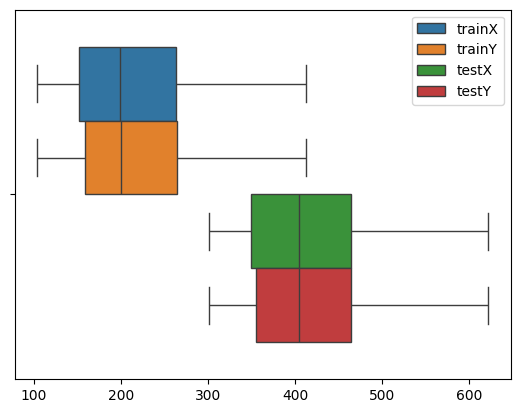

In [ ]:
# mostrando a escala de valores original dos dados
all_values = np.concatenate((trainX.squeeze(), trainY, testX.squeeze(), testY))
all_labels = ['trainX']*len(trainX) + ['trainY']*len(trainY) + ['testX']*len(testX) + ['testY']*len(testY)
sns.boxplot(x=all_values, hue=all_labels)

In [ ]:
# normalizar o dataset
scaler = MinMaxScaler(feature_range=(0, 1))
# calculamos as informações necessárias para o scaler usando apenas os valores de treino
trainX = scaler.fit_transform(trainX.reshape(-1, 1))
trainY = scaler.transform(trainY.reshape(-1, 1)) # apenas transformar
testX = scaler.transform(testX.reshape(-1, 1))
testY = scaler.transform(testY.reshape(-1, 1))

<Axes: >

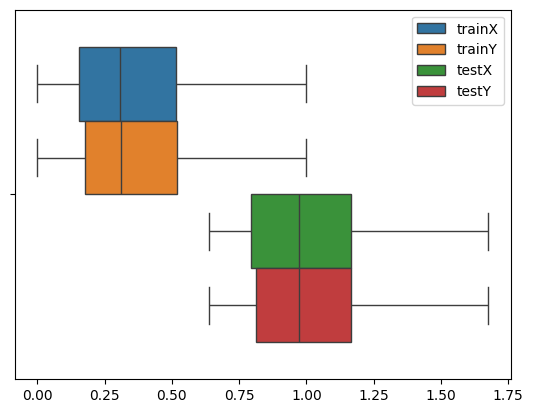

In [ ]:
# mostrando a nova escala dos dados
all_values = np.concatenate((trainX, trainY, testX, testY))
all_labels = ['trainX']*len(trainX) + ['trainY']*len(trainY) + ['testX']*len(testX) + ['testY']*len(testY)
sns.boxplot(x=all_values.squeeze(), hue=all_labels)

In [ ]:
# reshape entrada na forma [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [ ]:
# criando and fit the LSTM network

NN_model = Sequential()

# The Input Layer :
NN_model.add(LSTM(100, return_sequences=True,input_shape=(trainX.shape[0],trainX.shape[1])))
NN_model.add(Dropout(0.1))

# The Hidden Layers :
NN_model.add(LSTM(units=50, return_sequences=True))
NN_model.add(Dropout(0.1))
NN_model.add(LSTM(units=100))
NN_model.add(Dropout(0.1))


# The Output Layer :
NN_model.add(Dense(units=1))

# Compile the network :
NN_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])

NN_model.summary()

# Checkpoint
checkpoint_name = 'Weights-{epoch:03d}--{val_loss:.5f}.keras'
checkpoint = callbacks.ModelCheckpoint(checkpoint_name, monitor='val_loss', verbose = 1, save_best_only = True, mode ='auto')
callbacks_list = [checkpoint]


history = NN_model.fit(trainX, trainY, epochs = 100,validation_split = 0.1,batch_size = 16, shuffle = False,
                     verbose=2)



/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 94, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 94, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 94, 50)              │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 94, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100)                 │          60,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131,501 (513.68 KB)

 Trainable params: 131,501 (513.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 - 5s - 874ms/step - loss: 0.1232 - mean_squared_error: 0.1232 - val_loss: 0.5411 - val_mean_squared_error: 0.5411
Epoch 2/100
6/6 - 0s - 13ms/step - loss: 0.1074 - mean_squared_error: 0.1074 - val_loss: 0.4954 - val_mean_squared_error: 0.4954
Epoch 3/100
6/6 - 0s - 14ms/step - loss: 0.0898 - mean_squared_error: 0.0898 - val_loss: 0.4395 - val_mean_squared_error: 0.4395
Epoch 4/100
6/6 - 0s - 23ms/step - loss: 0.0707 - mean_squared_error: 0.0707 - val_loss: 0.3708 - val_mean_squared_error: 0.3708
Epoch 5/100
6/6 - 0s - 23ms/step - loss: 0.0508 - mean_squared_error: 0.0508 - val_loss: 0.2895 - val_mean_squared_error: 0.2895
Epoch 6/100
6/6 - 0s - 25ms/step - loss: 0.0332 - mean_squared_error: 0.0332 - val_loss: 0.2021 - val_mean_squared_error: 0.2021
Epoch 7/100
6/6 - 0s - 17ms/step - loss: 0.0230 - mean_squared_error: 0.0230 - val_loss: 0.1273 - val_mean_squared_error: 0.1273
Epoch 8/100
6/6 - 0s - 28ms/step - loss: 0.0241 - mean_squared_error: 0.0241 - val_loss: 0.0854 

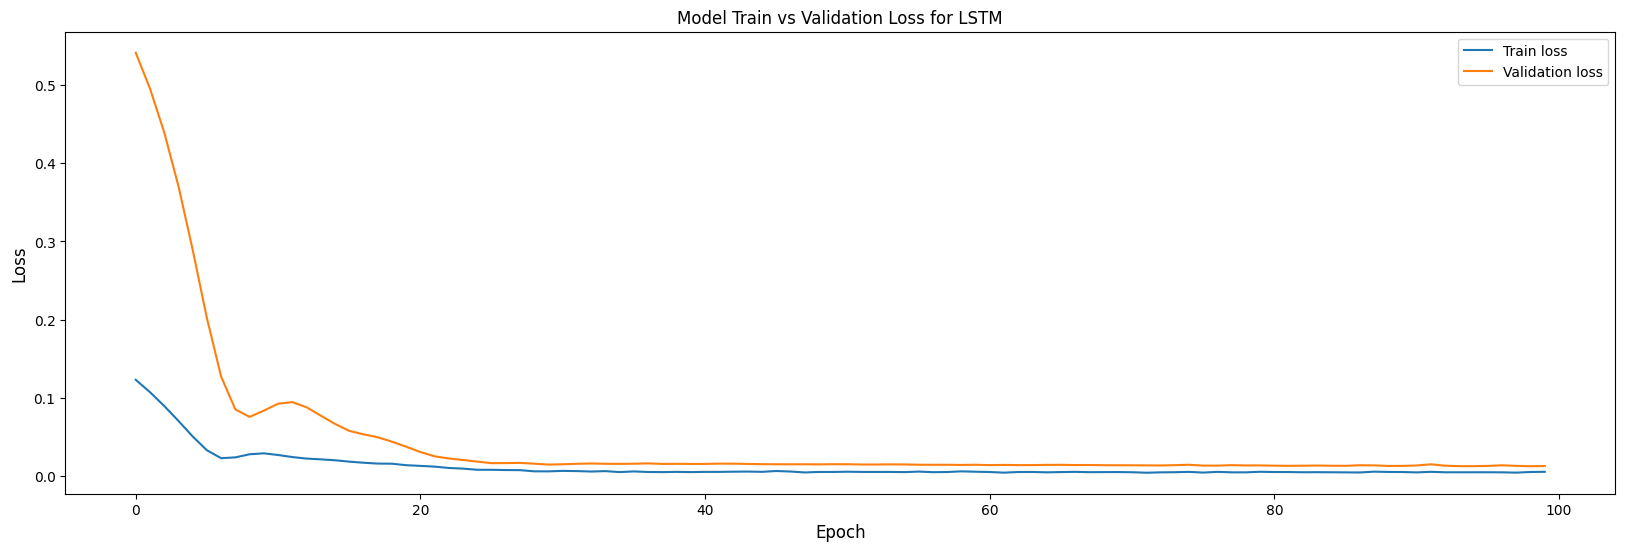

In [ ]:
#train loss x validation loss
plt.figure(figsize = (20, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Train vs Validation Loss for LSTM',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.xlabel('Epoch',fontsize=12)
plt.legend(['Train loss', 'Validation loss'], loc=0)

In [ ]:
# obtendo predições sobre o conjunto de treino
trainPredict = NN_model.predict(trainX)
# novamente, voltando os valores preditos para a escala original
trainPredict = scaler.inverse_transform(trainPredict)
trainY_original = scaler.inverse_transform(trainY)

# computando predições no conjunto de teste
LSTM_test_prediction = NN_model.predict(testX)
# retornando os valores para a escala original dos valores usando o inverse transform
testPredict = scaler.inverse_transform(LSTM_test_prediction)
testY_original = scaler.inverse_transform(testY)

trainRMSE = math.sqrt(mean_squared_error(trainY_original.reshape(-1,1), trainPredict[:,0]))
trainMAE = mean_absolute_error(trainY_original.reshape(-1,1), trainPredict[:,0])
print('Train RMSE: %.2f' % (trainRMSE))
print('Train MAE: %.2f' % (trainMAE))
print()

testRMSE = math.sqrt(mean_squared_error(testY_original.reshape(-1,1), testPredict[:,0]))
testMAE = mean_absolute_error(testY_original.reshape(-1,1), testPredict[:,0])
print('Test RMSE: %.2f' % (testRMSE))
print('Test MAE: %.2f' % (testMAE))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Train RMSE: 22.94
Train MAE: 17.94

Test RMSE: 48.98
Test MAE: 41.66


In [ ]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

Vamos plotar o dataset original em azul, as predicoes para o conj. de treinamento em verde, e as predicoes dos dados de test em vermelho.

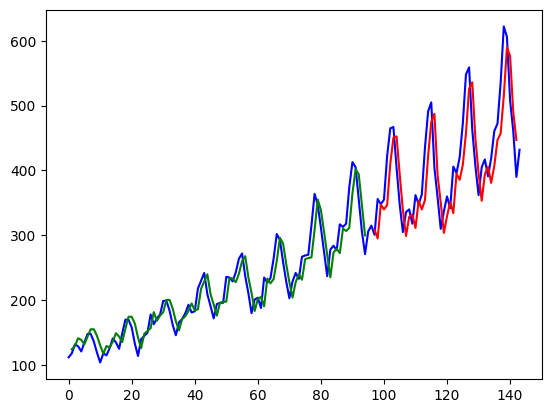

In [ ]:
# plot baseline and predictions
plt.plot(dataset, color="blue")
plt.plot(trainPredictPlot, color="green")
plt.plot(testPredictPlot, color="red")
plt.show()

Podemos ver que o modelo tem um erro médio de cerca de 23 passageiros (em milhares) no conjunto de dados de treinamento e cerca de 50 passageiros (em milhares) no conjunto de dados de teste. Não tão ruim.

####**LSTM for Regression Using the Window Method**

Também podemos formular o problema de forma que várias timesteps recentes possam ser usadas para fazer a previsão para o próximo timestep.

Isso é chamado de **janela**, e o tamanho da janela é um parâmetro que pode ser ajustado para cada problema.

Por exemplo, dado o tempo atual (t) que queremos prever o valor no próximo tempo na sequência (t + 1), podemos usar o tempo atual (t), bem como os dois tempos anteriores (t-1 e t-2) como variáveis ​​de entrada.

Quando formulado como um problema de regressão, as variáveis ​​de entrada são t-2, t-1, t e a variável de saída é t + 1.

A função **create_dataset()** criada nos permite allows criar esta formulação aumentando a var. **look_back** de 1 para 3.

Exemplo: 112  118  132  129  121 135 148   ...... </br>
X1	 X2	 X3	 Y <br>
112	118	132	129 <br>
118	132	129	121 <br>
132	129	121	135 <br>
129	121	135	148 <br>
121	135	148	148 <br>
....            <br>

In [ ]:
## LSTM para o problema para passageiros em Cia Aerea Intern. com Memoria
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


# Carregar o dataset
dataframe = read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv', usecols=[1], engine='python')
dataset = dataframe.values
dataset = dataset.astype('float64')

# separar em conjuntos de train and test
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]


# reshape em X=t and Y=t+1
look_back = 3
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)
new_data=pd.DataFrame()

In [ ]:
# normalizar o dataset
scaler = MinMaxScaler(feature_range=(0, 1))
prev_train_shape = trainX.shape
prev_test_shape = testX.shape
# calculamos as informações necessárias para o scaler usando apenas os valores de treino
trainX = scaler.fit_transform(trainX.reshape(-1, 1))
trainY = scaler.transform(trainY.reshape(-1, 1)) # apenas transformar
testX = scaler.transform(testX.reshape(-1, 1))
testY = scaler.transform(testY.reshape(-1, 1))

In [ ]:
# retomando o shape original
trainX = trainX.reshape(prev_train_shape)
testX = testX.reshape(prev_test_shape)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 - 1s - 16ms/step - loss: 0.0722
Epoch 2/100
92/92 - 0s - 2ms/step - loss: 0.0196
Epoch 3/100
92/92 - 0s - 3ms/step - loss: 0.0172
Epoch 4/100
92/92 - 0s - 2ms/step - loss: 0.0151
Epoch 5/100
92/92 - 0s - 3ms/step - loss: 0.0137
Epoch 6/100
92/92 - 0s - 3ms/step - loss: 0.0127
Epoch 7/100
92/92 - 0s - 2ms/step - loss: 0.0121
Epoch 8/100
92/92 - 0s - 2ms/step - loss: 0.0115
Epoch 9/100
92/92 - 0s - 3ms/step - loss: 0.0110
Epoch 10/100
92/92 - 0s - 2ms/step - loss: 0.0106
Epoch 11/100
92/92 - 0s - 2ms/step - loss: 0.0102
Epoch 12/100
92/92 - 0s - 3ms/step - loss: 0.0098
Epoch 13/100
92/92 - 0s - 2ms/step - loss: 0.0095
Epoch 14/100
92/92 - 0s - 3ms/step - loss: 0.0091
Epoch 15/100
92/92 - 0s - 2ms/step - loss: 0.0088
Epoch 16/100
92/92 - 0s - 2ms/step - loss: 0.0085
Epoch 17/100
92/92 - 0s - 3ms/step - loss: 0.0081
Epoch 18/100
92/92 - 0s - 2ms/step - loss: 0.0078
Epoch 19/100
92/92 - 0s - 3ms/step - loss: 0.0076
Epoch 20/100
92/92 - 0s - 3ms/step - loss: 0.0073
Epoch 21/100
92/92 -

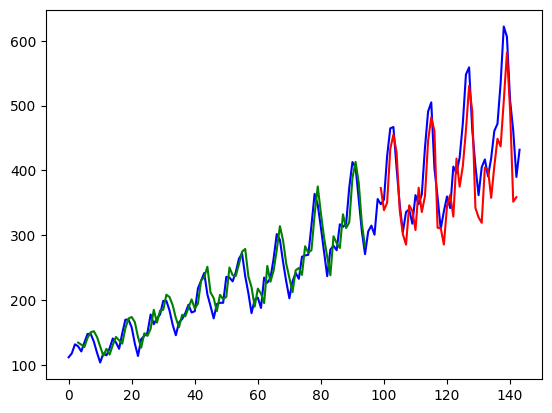

In [ ]:
# reshape as entradas na forma [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
# cria e aplica a rede LSTM
model = Sequential()
model.add(LSTM(30, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)
# fazer as predicoes
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
# inverter as predicoes
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY)
# calcular o RMSE - root mean squared error
trainScore = math.sqrt(mean_squared_error(trainY.reshape(-1,1), trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY.reshape(-1,1), testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))
# shift prediçoes de treinamento para fazer o plot
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
# shift prediçoes de teste para fazer o plot
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict
# plot original and predicoes
plt.plot(dataset, color = "blue")
plt.plot(trainPredictPlot, color="green")
plt.plot(testPredictPlot, color="red")
plt.show()

Podemos ver que o erro no conjunto diminuiu em relação ao da seção anterior. Uma arquitetura mais simples parece ser mais adequada ao problema.